# **Mission 3: Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [1]:
# importing pandas
import pandas as pd

# Creating DataFrame sales, invoice and product
df_sales = pd.read_excel(f'{notebookutils.nbResPath}/builtin/online_sales_retailer.xlsx', sheet_name = 'Sales')
df_invoice = pd.read_excel(f'{notebookutils.nbResPath}/builtin/online_sales_retailer.xlsx', sheet_name = 'Invoice')
df_product = pd.read_excel(f'{notebookutils.nbResPath}/builtin/online_sales_retailer.xlsx', sheet_name = 'Product')

# Display first few rows of each DataFrame
display(df_sales.head())
display(df_invoice.head())
display(df_product.head())

### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Check for missing values in the Sales DataFrame.

2. Replace any NaN values in the Sales and UnitPrice columns with 0.

3. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

#### **Task 2.1** - Handling missing values

In [2]:
# Check for missing values
missing_values = df_sales.isnull()

# Display only rows with null values
rows_with_nulls = df_sales[missing_values.any(axis=1)]

# Display the rows with null values
display(rows_with_nulls)

#### **Task 2.2** - There are no NaN values in Sales DataFrame.

#### **Task 2.3** - Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [3]:
# Summary statistics for Quantity
Mean_Quantity = df_sales['Quantity'].mean()
Median_Quantity = df_sales['Quantity'].median()
Mode_Quantity = df_sales['Quantity'].mode()[0]
STD_Quantity = df_sales['Quantity'].std()

# Summary statistics for UnitPrice
Mean_UnitPrice = df_sales['UnitPrice'].mean()
Median_UnitPrice = df_sales['UnitPrice'].median()
Mode_UnitPrice = df_sales['UnitPrice'].mode()[0]
STD_UnitPrice = df_sales['UnitPrice'].std()

# Display results
print(f"""
Quantity Statistics
Mean: {Mean_Quantity}
Median: {Median_Quantity}
Mode: {Mode_Quantity}
Std Dev: {STD_Quantity}")

UnitPrice Statistics
Mean: {Mean_UnitPrice}
Median UnitPrice: {Median_UnitPrice}
Mode: {Mode_UnitPrice}
Std Dev: {STD_UnitPrice}
""")



Quantity Statistics
Mean: 13.610961009642518
Median: 6.0
Mode: 1
Std Dev: 261.57756533193884")

UnitPrice Statistics
Mean: 3.0835027678710816
Median UnitPrice: 1.95
Mode: 1.25
Std Dev: 5.17765256537552



### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

#### **Task 3.1** - Merge Sales DataFrame with Invoice DataFrame

In [4]:
## Merging Sales DataFrame with Invoice DataFrame
df_combined = pd.merge(df_sales, df_invoice, on='InvoiceNo')
display(df_combined.head())

#### **Task 3.2** - Merge Combined DataFrame with Product DataFrame

In [5]:
# Merge the result with the Product DataFrame on StockCode
df_merged = pd.merge(df_combined, df_product, on='StockCode')
display(df_merged.head())

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [6]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 13.7 MB/s eta 0:00:00


#### **Task 4.1** - Use describe() to calculate summary statistics for numeric columns.

In [7]:
## Calculating summary of Quantity and UnitPrice
df_merged[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,83277.000000,83277.000000
mean,13.610961,3.083503
std,261.577565,5.177653
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,74215.000000,295.000000


#### **Task 4.2** - Perform basic filtering, such as filtering out sales with Quantity equal to 0.

In [8]:
# Filtering out sales with Quantity equal to 0.
df_filtered = df_merged[df_merged['Quantity'] == 0]
display(df_filtered.head())

##### **Summary** :-
##### There are no Quantities with 0 values

#### **Task 4.3** - Check for outliers in the Sales column by using a scatter plot.

In [9]:
# Creating a new column Sales
df_merged['Sales'] = df_merged['Quantity'] * df_merged['UnitPrice']
display(df_merged.head())

In [10]:
# Checking for Sales summary
df_merged[['Sales']].describe()

,Sales
count,83277.000000
mean,23.121043
std,278.041319
min,0.000000
25%,5.000000
50%,12.500000
75%,19.500000
max,77183.600000


In [11]:
#Checking for max sales value
df_merged[df_merged['Sales'] == df_merged['Sales'].max()]

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Country,Description,Product_Category,Sales
81701,548691,23166,74215,1.04,2016-10-10,United Kingdom,CHRISTMAS RETROSPOT STAR WOOD,CHRISTMAS,77183.6


In [12]:
#Checking for min sales value
df_merged[df_merged['Sales'] == df_merged['Sales'].min()]

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Country,Description,Product_Category,Sales
14414,547817,22168,1,0.0,2016-08-25,United Kingdom,MEDIUM CHINESE STYLE SCISSOR,SCISSOR,0.0
26581,545980,22553,24,0.0,2016-05-21,United Kingdom,FROG KING WATERING CAN,WATERING,0.0
32345,543850,22580,4,0.0,2016-01-29,United Kingdom,ANTIQUE GLASS PEDESTAL BOWL,BOWL,0.0
37375,544786,22423,10,0.0,2016-03-19,United Kingdom,BLUE POLKADOT COFFEE MUG,MUG,0.0
56805,545984,22090,24,0.0,2016-05-21,United Kingdom,BLUE PADDED SOFT MOBILE,PADDED,0.0
59364,538661,22841,1,0.0,2015-05-01,United Kingdom,STORAGE TIN HOME SWEET HOME,TIN,0.0
70365,554220,84535,16,0.0,2017-07-28,United Kingdom,GLASS CHALICE GREEN SMALL,GLASS,0.0


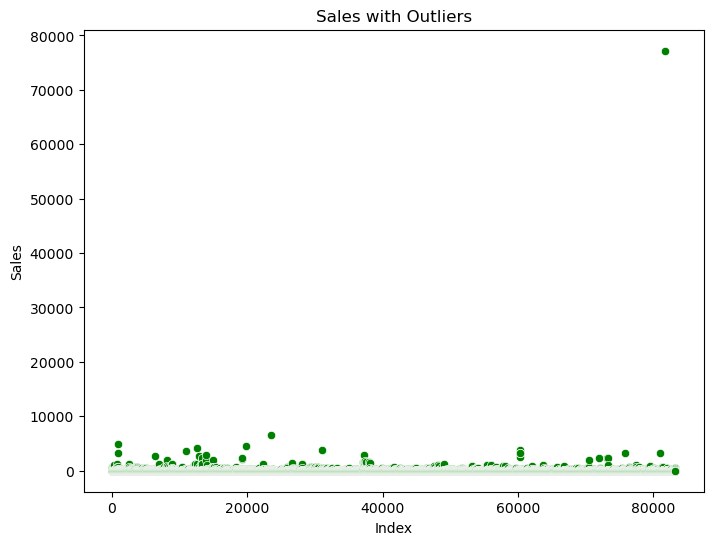

In [13]:
# Checking for outliers in the Sales column by using a scatter plot.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_merged.index, y='Sales', data=df_merged, color='green')
plt.title('Sales with Outliers')
plt.xlabel('Index')
plt.ylabel('Sales')
plt.show()

In [14]:
# Filtering out outliers
df_outlier_filtered = df_merged[(df_merged['Sales'] != 77183.6) & (df_merged['Sales'] != 0)].copy()

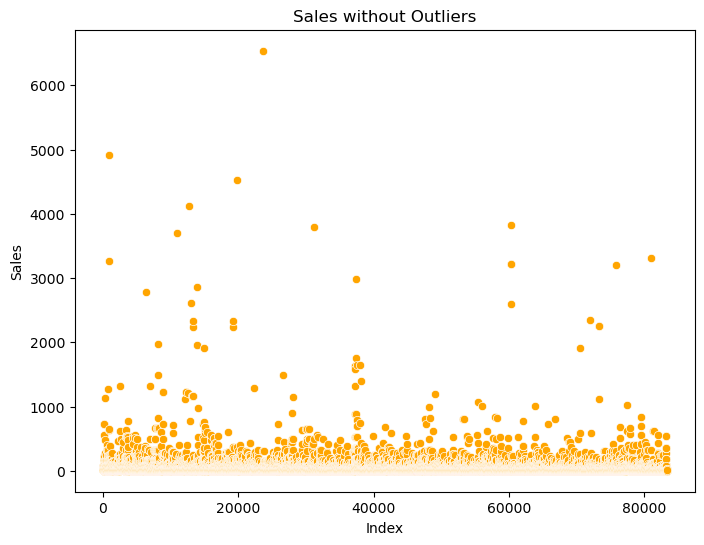

In [15]:
# Scatter plot after filtering outliers 
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_outlier_filtered.index, y='Sales', data=df_outlier_filtered, color='orange')
plt.title('Sales without Outliers')
plt.xlabel('Index')
plt.ylabel('Sales')
plt.show()

##### **Summary** :-
##### **Sales with Outliers:**
- ##### Shows one extremely large sales value (~77k), which stretches the y‑axis and compresses all other points near the bottom, making patterns hard to see.
##### **Sales without Outliers:**
- ##### After removing 77,183.6 and 0, the plot scales normally. The remaining sales values spread out clearly, making the data easier to read and analyze.

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.


#### **Task 5.1** - Use a scatter plot to examine the relationship between Quantity and Sales.

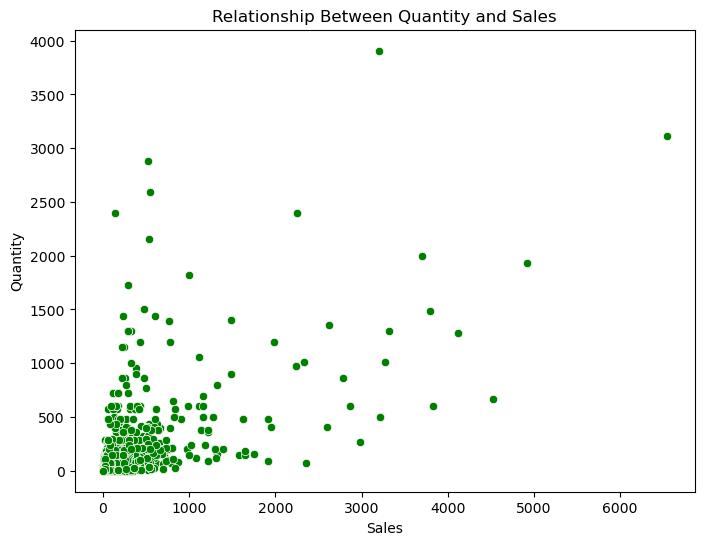

In [16]:
# Scatter plot to visualise the relationship between Quantity and Sales without outlier
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Sales', y='Quantity', data=df_outlier_filtered, color='green')
plt.title('Relationship Between Quantity and Sales')
plt.xlabel('Sales')
plt.ylabel('Quantity')
plt.show()

##### **Summary** :-
- ##### The scatter plot indicates a generally positive relationship between Sales and Quantity, where higher quantities tend to be associated with higher sales values. 
- ##### Most observations are concentrated in the lower range, showing that the majority of transactions involve small quantities and lower sales amounts. 
- ##### A few data points appear far from the main cluster, suggesting the presence of outliers with unusually high sales or quantities, which may influence the overall trend and should be considered during further analysis.

#### **Task 5.2** - Use a histogram to visualise the distribution of the Sales column

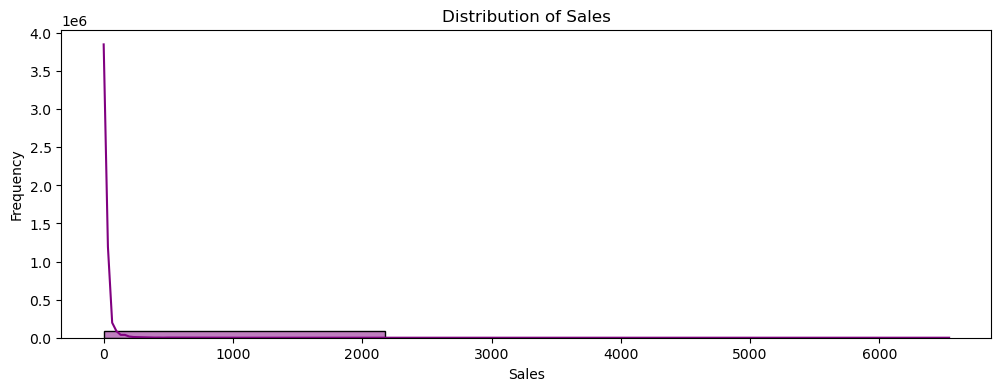

In [17]:
# Creating a histogram to visualise the distribution of the Sales column
plt.figure(figsize=(12, 4))
sns.histplot(df_outlier_filtered['Sales'], bins=3, color='purple', kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

##### **Summary** :-
- ##### The histogram shows that most sales values are very small, and only a few sales values are very large. 
- ##### Because of this, the bars are high near the left side and almost flat on the right side. 
- ##### This means the sales data is not evenly spread and is right‑skewed.

#### **Task 5.3** - Use a line chart to show the trend of Sales over time

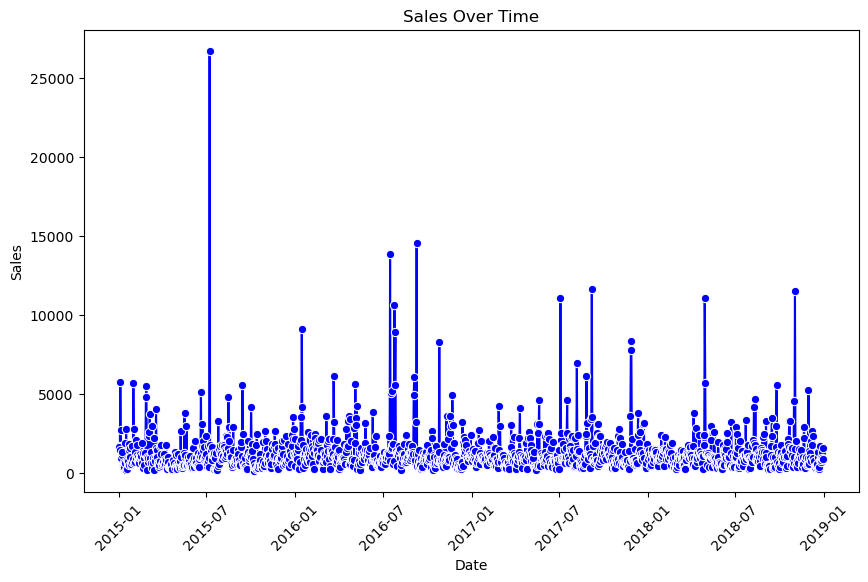

In [18]:
# Creating a line chart to show the trend of Sales over time
plt.figure(figsize=(10, 6))
df_sales_overtime = df_outlier_filtered.groupby('InvoiceDate')['Sales'].sum().reset_index()
sns.lineplot(x='InvoiceDate', y='Sales', data= df_sales_overtime, marker='o', color='blue')
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

##### **Summary** :-
- ##### The chart shows how sales changed over time. 
- ##### Most sales amounts stay low, but there are a few big spikes on certain dates. 
- ##### This means sales were mostly steady with occasional very high jumps.

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

          Quantity     Sales
Quantity  1.000000  0.661122
Sales     0.661122  1.000000





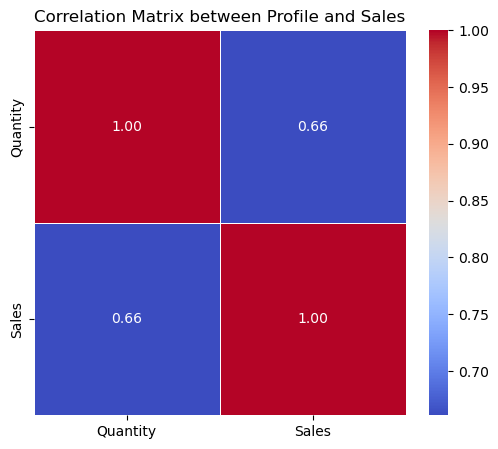

In [19]:
# Calculate correlation between 'Quantity' and 'Sales'
correlation = df_outlier_filtered[['Quantity', 'Sales']].corr()

# Display the correlation matrix
print(correlation)

# add 2 blank rows
print('\n\n')

# Create a heatmap for the correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix between Profile and Sales')
plt.show()

##### **Summary :-**
- ##### The heatmap shows that Quantity and Sales have a moderate positive relationship (0.66). 
- ##### This means that when quantity increases, sales usually increase too.

## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

#### **Task 7.1** - Groupby operation

In [20]:
# Group by Product_Category and calculate total Sales
sales_by_category = df_outlier_filtered.groupby('Product_Category')['Sales'].sum().reset_index()
sales_by_category = sales_by_category.sort_values(by='Sales', ascending=False)

# Display the grouped data
display(sales_by_category)

#### **Task 7.2** - Pivot Table

In [21]:
# Creating a pivot table for Sales by Country and Product_Category
pivot_table = df_outlier_filtered.pivot_table(values='Sales', index='Country', columns='Product_Category', aggfunc='sum')

# Reset the index to make 'StoreName' a normal column
pivot_table = pivot_table.reset_index()

# Display the pivot table
display(pivot_table)

##### **Summary** :-
- ##### Uncategorised products generated the highest sales, making it the top-earning category.
- ##### CANDLE, GLASS, and MUG categories show strong sales performance, contributing significantly to total revenue.
- ##### Categories like LIGHTS, DECORATION, and SIGN also perform well, with solid mid-range sales.
- ##### STOOL, BOX, and TIN categories show moderate sales, contributing steadily.
- ##### Overall, revenue is mainly driven by a few high‑performing home and decor categories, while other categories contribute smaller but consistent amounts.

## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Great work! Amazing visual and methodology!I love the professional way you explain your approach and provide insights, very well done! Jose A